# Chest X-Ray Pneumonia (Transfer Learning Experiment )
- ### ResNet50 FineTuning Experiment Analysis

## 1. Environment
분석 환경에 따라 프로젝트와 공통 라이브러리 경로를 설정합니다.

In [1]:
## PC 전용(기본 경로)
import sys

sys.path.insert(0, r"D:\DEV\AI\src")
sys.path.insert(0, r"D:\DEV\AI\projects\chest-xray-pneumonia")

In [3]:
import sys
import importlib

# ============================================================
# Environment
# ============================================================ 
ENV = "pc"  

# ============================================================
# Project Configuration
# ============================================================

import cxp.cxp_config as cxp_config

importlib.reload(cxp_config)

config = cxp_config.configure_environment(ENV)


# ============================================================
# Python Path
# ============================================================

PROJECT_ROOT = config["PROJECT_ROOT"]
AILIB_ROOT = config["AILIB_ROOT"]

if str(AILIB_ROOT) not in sys.path:
    sys.path.insert(0, str(AILIB_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# Project Configuration
# ============================================================

DATA_ROOT = config["DATA_ROOT"]
PROCESSED_DATA_DIR = config["PROCESSED_DATA_DIR"]

TRAIN_DIR = config["TRAIN_DIR"]
VAL_DIR = config["VAL_DIR"]
TEST_DIR = config["TEST_DIR"]

IMAGE_INFO_CSV  = config["IMAGE_INFO_CSV"]

LOCAL_TRAIN_DIR = config["LOCAL_TRAIN_DIR"]
LOCAL_VAL_DIR = config["LOCAL_VAL_DIR"]
LOCAL_TEST_DIR = config["LOCAL_TEST_DIR"]

DATASET_TRAIN_DIR = config["DATASET_TRAIN_DIR"]
DATASET_VAL_DIR = config["DATASET_VAL_DIR"]
DATASET_TEST_DIR = config["DATASET_TEST_DIR"]

EXPERIMENTS_DIR = config["EXPERIMENTS_DIR"]
MODELS_DIR = config["MODELS_DIR"]
REPORTS_DIR = config["REPORTS_DIR"]

CLASS_TO_IDX = config["CLASS_TO_IDX"]
IDX_TO_CLASS = config["IDX_TO_CLASS"]


# ============================================================
# Environment Check
# ============================================================

print("=" * 60)
print("Environment Configuration")
print("=" * 60)

print(f"Environment     : {ENV}")
print(f"Project Root    : {PROJECT_ROOT}")
print(f"AI Library      : {AILIB_ROOT}")
print(f"Experiments Dir : {EXPERIMENTS_DIR}")
print(f"Reports Dir     : {REPORTS_DIR}")

print("=" * 60)

Environment Configuration
Environment     : pc
Project Root    : D:\DEV\AI\projects\chest-xray-pneumonia
AI Library      : D:\DEV\AI\src
Experiments Dir : D:\DEV\AI\projects\chest-xray-pneumonia\experiments
Reports Dir     : D:\DEV\AI\projects\chest-xray-pneumonia\reports


In [4]:
import plotly.io as pio

# 깃허브에서 보이도록 기본 렌더러를 정적 이미지로 변경
pio.renderers.default = "png" 
# 만약 화질이 깨져서 선명하게 보고 싶다면 "svg"를 사용하셔도 됩니다.

## 2. Load Reports 

In [5]:
# ============================================================
# 2. Load Experiment Reports
# ============================================================

from pathlib import Path
import pandas as pd

REPORTS_DIR = Path(REPORTS_DIR)

metadata_path = REPORTS_DIR / "experiment_metadata.csv"
history_path = REPORTS_DIR / "experiment_history.csv"

experiment_summary = pd.read_csv(metadata_path)
history_df = pd.read_csv(history_path)

print("=" * 60)
print("Loaded Experiment Reports")
print("=" * 60)

print(f"Metadata : {metadata_path}")
print(f"History  : {history_path}")

print()
print(f"Summary shape : {experiment_summary.shape}")
print(f"History shape : {history_df.shape}")

Loaded Experiment Reports
Metadata : D:\DEV\AI\projects\chest-xray-pneumonia\reports\experiment_metadata.csv
History  : D:\DEV\AI\projects\chest-xray-pneumonia\reports\experiment_history.csv

Summary shape : (14, 20)
History shape : (230, 8)


## 3. Experiment List
 

In [6]:
# ============================================================
# 3. Experiment List
# ============================================================

experiment_names = experiment_summary["experiment"].unique()

print("=" * 60)
print("Experiments")
print("=" * 60)

for i, name in enumerate(experiment_names, 1):

    runs = experiment_summary.loc[
        experiment_summary["experiment"] == name,
        "run"
    ].tolist()

    print(f"{i}. {name}")
    print(f"   Runs: {runs}")

Experiments
1. TL-DENSENET121-FULL
   Runs: ['LR1', 'LR2']
2. TL-DENSENET121-LR
   Runs: ['LR1', 'LR2']
3. TL-DENSENET121-PARTIAL
   Runs: ['LR1', 'LR2']
4. TL-RESNET50-FULL
   Runs: ['LR2', 'LR2-EPOCH20']
5. TL-RESNET50-LR
   Runs: ['LR1', 'LR2', 'LR2-EPOCH20', 'LR3']
6. TL-RESNET50-PARTIAL
   Runs: ['LR2', 'LR2-EPOCH20']


## 4.  Experiment Metadata

In [7]:
# ============================================================
# 4.  Experiment Metadata
# ============================================================

overview_columns = [
    "experiment",
    "run",
    "model",
    "image_size",
    "normalization",
    "augmentation",
    "batch_size",
    "optimizer",
    "learning_rate",
    "num_epochs",
    "best_epoch",
    "best_validation_loss",
    "best_validation_accuracy",
]

display(
    experiment_summary[overview_columns]
    .sort_values(
        ["experiment", "run"]
    )
    .reset_index(drop=True)
)

,experiment,run,model,image_size,normalization,augmentation,batch_size,optimizer,learning_rate,num_epochs,best_epoch,best_validation_loss,best_validation_accuracy
0,TL-DENSENET121-FULL,LR1,DenseNet,512,imagenet_mean_std,none,16,Adam,0.00100,20,17,0.032354,0.992337
1,TL-DENSENET121-FULL,LR2,DenseNet,512,imagenet_mean_std,none,16,Adam,0.00010,20,13,0.007616,0.996169
2,TL-DENSENET121-LR,LR1,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00100,20,17,0.085301,0.969349
3,TL-DENSENET121-LR,LR2,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00010,20,20,0.164848,0.944444
4,TL-DENSENET121-PARTIAL,LR1,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00100,20,15,0.020797,0.995211
5,TL-DENSENET121-PARTIAL,LR2,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00010,20,10,0.029739,0.990421
6,TL-RESNET50-FULL,LR2,ResNet,512,imagenet_mean_std,none,16,Adam,0.00010,10,10,0.016960,0.993295
7,TL-RESNET50-FULL,LR2-EPOCH20,ResNet,512,imagenet_mean_std,none,16,Adam,0.00010,20,7,0.018109,0.993295
8,TL-RESNET50-LR,LR1,ResNet,512,train_mean_std,none,64,Adam,0.00100,10,10,0.115350,0.954023
9,TL-RESNET50-LR,LR2,ResNet,512,train_mean_std,none,64,Adam,0.00010,10,10,0.239991,0.918582


## 5. Validation Loader

In [10]:
# ============================================================
# 5. Validation Loader
# ============================================================

import json

from ailib.data_split_v2 import split_train_validation
from ailib.transform_v2 import create_transform
from ailib.dataset_v2 import ImageDataset
from ailib.dataloader_v2 import create_dataloader


# ============================================================
# Batch Size : 실험환경에 따라 변경
# ============================================================

BATCH_SIZE = 16


# ============================================================
# Load Split Metadata
# ============================================================

split_config_path = REPORTS_DIR / "split_config.json"

if not split_config_path.exists():
    raise FileNotFoundError(
        f"Split metadata not found: {split_config_path}"
    )

with open(
    split_config_path,
    "r",
    encoding="utf-8",
) as f:
    split_config = json.load(f)


# ============================================================
# Split Configuration
# ============================================================

VAL_SIZE = split_config["validation"]["size"]
RANDOM_STATE = split_config["validation"]["random_state"]
STRATIFY_COLUMN = split_config["validation"]["stratify_column"]


# ============================================================
# Preprocessing Configuration
# ============================================================

IMAGE_SIZE = split_config["preprocessing"]["image_size"]
NORMALIZATION = split_config["preprocessing"]["normalization"]


# ============================================================
# Load Dataset Metadata
# ============================================================

image_info = pd.read_csv(IMAGE_INFO_CSV)


# ============================================================
# Recreate Train / Validation Split
# ============================================================

train_df, val_df = split_train_validation(
    dataframe=image_info,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify_column=STRATIFY_COLUMN,
)


# ============================================================
# Validation Transform
# ============================================================

eval_transform = create_transform(
    image_size=IMAGE_SIZE,
    mean=NORMALIZATION["mean"],
    std=NORMALIZATION["std"],
)


# ============================================================
# Validation Dataset
# ============================================================

val_dataset = ImageDataset(
    dataframe=val_df,
    data_dir=DATASET_TRAIN_DIR,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform,
)


# ============================================================
# Validation DataLoader
# ============================================================

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ============================================================
# Result
# ============================================================

print("=" * 60)
print("Validation Loader")
print("=" * 60)

print(f"Split Version : {split_config['version']}")
print(f"Validation    : {len(val_dataset)}")
print(f"Image Size    : {IMAGE_SIZE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Shuffle       : False")
print("=" * 60)

Validation Loader
Split Version : 1.0
Validation    : 1044
Image Size    : 512
Batch Size    : 16
Shuffle       : False


##  Analysis 

### 1. Analysis Configuration

In [13]:
# ============================================================
# Analysis
# 1. Analysis Configuration
# ============================================================

import json
from pathlib import Path

import pandas as pd
import torch
from ailib.device import get_device


# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------

SELECTED_EXPERIMENTS = [
    "TL-RESNET50-FULL",
    "TL-RESNET50-PARTIAL", 
]

DEVICE = get_device()


print(f"Device: {DEVICE}")
print(f"Selected Experiments: {SELECTED_EXPERIMENTS}")

Device: cuda
Selected Experiments: ['TL-RESNET50-FULL', 'TL-RESNET50-PARTIAL']


### 2. Experiment Selection

### 추가 실험 -> 실험 결정

* **ResNet50 — Epoch 확장:** 초기 학습에서 충분히 학습되지 않은 것으로 판단하여 Epoch을 20으로 확장하였다.
<!-- * **DenseNet121 — Learning Rate 변경:** Validation 성능의 변동이 확인되어 Learning Rate를 낮춰 추가 실험하였다. -->


In [14]:
# ============================================================
# 2. Experiment Selection
# ============================================================

SELECTED_RUNS = [
    ("TL-RESNET50-FULL", "LR2-EPOCH20"),
    ("TL-RESNET50-PARTIAL", "LR2-EPOCH20"),
]

selected_summary = experiment_summary[
    experiment_summary.apply(
        lambda row: (row["experiment"], row["run"]) in SELECTED_RUNS,
        axis=1,
    )
].copy()

selected_summary = (
    selected_summary
    .sort_values(["experiment", "run"])
    .reset_index(drop=True)
)

print(f"Experiments: {selected_summary['experiment'].nunique()}")
print(f"Runs: {len(selected_summary)}")

display(
    selected_summary[
        ["experiment", "run", "model", "learning_rate", "num_epochs"]
    ]
)

Experiments: 2
Runs: 2


,experiment,run,model,learning_rate,num_epochs
0,TL-RESNET50-FULL,LR2-EPOCH20,ResNet,0.0001,20
1,TL-RESNET50-PARTIAL,LR2-EPOCH20,ResNet,0.0001,20


### 3. Selected Experiment Overview

In [15]:
# ============================================================
# 3. Selected Experiment Overview
# ============================================================

overview_columns = [
    "experiment",
    "run",
    "model",
    "image_size",
    "normalization",
    "augmentation",
    "batch_size",
    "optimizer",
    "learning_rate",
    "num_epochs",
    "best_epoch",
    "best_validation_loss",
    "best_validation_accuracy",
]

available_columns = [
    column
    for column in overview_columns
    if column in selected_summary.columns
]

display(
    selected_summary[
        available_columns
    ].reset_index(drop=True)
)

,experiment,run,model,image_size,normalization,augmentation,batch_size,optimizer,learning_rate,num_epochs,best_epoch,best_validation_loss,best_validation_accuracy
0,TL-RESNET50-FULL,LR2-EPOCH20,ResNet,512,imagenet_mean_std,none,16,Adam,0.0001,20,7,0.018109,0.993295
1,TL-RESNET50-PARTIAL,LR2-EPOCH20,ResNet,512,imagenet_mean_std,none,64,Adam,0.0001,20,4,0.040995,0.985632


### 4. Validation Evaluation

#### 4-1. Model Load

In [16]:
# ============================================================
# 4. Validation Evaluation
# 4-1. Model Load
# ============================================================

from cxp.cxp_model import (
    build_transfer_model,
    configure_fine_tuning,
)


def load_experiment_model(run_info):
    """
    Load a trained experiment model using experiment metadata.
    """

    experiment = run_info["experiment"]
    run = run_info["run"]

    model_path = (
        EXPERIMENTS_DIR
        / experiment
        / run
        / "model.pth"
    )

    # ========================================================
    # Model Configuration
    # ========================================================

    model_name = run_info["model"]
    channels = run_info["channels"]

    if model_name == "ResNet":
        model_name = "resnet50"

    # ========================================================
    # Fine-Tuning Mode
    # ========================================================

    if "FULL" in experiment:
        fine_tuning_mode = "full"
    elif "PARTIAL" in experiment:
        fine_tuning_mode = "partial"
    else:
        raise ValueError(
            f"Unknown fine-tuning experiment: {experiment}"
        )

    # ========================================================
    # Build Model
    # ========================================================

    model = build_transfer_model(
        model_name=model_name,
        num_classes=2,
        in_channels=channels,
        pretrained=True,
    )

    # ========================================================
    # Configure Model
    # ========================================================

    model = configure_fine_tuning(
        model=model,
        model_name=model_name,
        fine_tuning_mode=fine_tuning_mode,
    )

    # ========================================================
    # Load Checkpoint
    # ========================================================

    checkpoint = torch.load(
        model_path,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint)

    model = model.to(DEVICE)
    model.eval()

    return model

#### 4-2. Run Evaluation

In [17]:
# ============================================================
# 4-2. Run Evaluation
# ============================================================

from cxp.cxp_evaluation import (
    predict,
    calculate_metrics,
)

validation_results = []
validation_predictions = {}

for _, run_info in selected_summary.iterrows():

    experiment = run_info["experiment"]
    run = run_info["run"]

    print(
        f"Evaluating: {experiment} / {run}"
    )

    # --------------------------------------------------------
    # Load Model
    # --------------------------------------------------------

    model = load_experiment_model(
        run_info
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    labels, predictions, probabilities = predict(
        model=model,
        loader=val_loader,
        device=DEVICE,
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics = calculate_metrics(
        labels=labels,
        predictions=predictions,
        probabilities=probabilities,
    )

    validation_results.append({
        "experiment": experiment,
        "run": run,
        **metrics,
    })

    # --------------------------------------------------------
    # Store Predictions
    # --------------------------------------------------------

    validation_predictions[(experiment, run)] = {
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
    }

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

Evaluating: TL-RESNET50-FULL / LR2-EPOCH20
Evaluating: TL-RESNET50-PARTIAL / LR2-EPOCH20


#### 4-3. Validation Metrics

In [29]:
# ============================================================
# 4-3. Validation Metrics
# ============================================================

validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = (
    validation_results_df
    .sort_values(
        "experiment",
        key=lambda s: s.map({
            "TL-RESNET50-PARTIAL": 0,
            "TL-RESNET50-FULL": 1,
        })
    )
    .reset_index(drop=True)
)

metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "roc_auc",
]

display(
    validation_results_df[
        ["experiment", "run"] + metric_columns
    ]
)

,experiment,run,accuracy,precision,recall,specificity,f1,roc_auc
0,TL-RESNET50-PARTIAL,LR2-EPOCH20,0.984674,0.993506,0.985825,0.981343,0.989651,0.998380
1,TL-RESNET50-FULL,LR2-EPOCH20,0.994253,0.996134,0.996134,0.988806,0.996134,0.999788


In [30]:
# ============================================================
# Validation Metrics - Percentage View
# ============================================================

display(
    validation_results_df[
        ["experiment", "run"] + metric_columns
    ]
    .style
    .format({
        column: "{:.4f}"
        for column in metric_columns
    })
)

,experiment,run,accuracy,precision,recall,specificity,f1,roc_auc
0,TL-RESNET50-PARTIAL,LR2-EPOCH20,0.9847,0.9935,0.9858,0.9813,0.9897,0.9984
1,TL-RESNET50-FULL,LR2-EPOCH20,0.9943,0.9961,0.9961,0.9888,0.9961,0.9998


In [32]:
# ============================================================
# Confusion Matrix Counts
# ============================================================

confusion_columns = [
    "tn",
    "fp",
    "fn",
    "tp",
]

display(
    validation_results_df[
        ["experiment", "run"] + confusion_columns
    ]
)

,experiment,run,tn,fp,fn,tp
0,TL-RESNET50-PARTIAL,LR2-EPOCH20,263,5,11,765
1,TL-RESNET50-FULL,LR2-EPOCH20,265,3,3,773


### 5. Experiment Comparison

#### 5-1. Classification Metrics

In [ ]:
# # ============================================================
# # 5. Experiment Comparison
# # 5-1. Classification Metrics
# # ============================================================

# # import importlib
# # import cxp.cxp_plot as cxp_plot

# # importlib.reload(cxp_plot)

# cxp_plot.plot_metric_comparison(
#     validation_results_df
# )

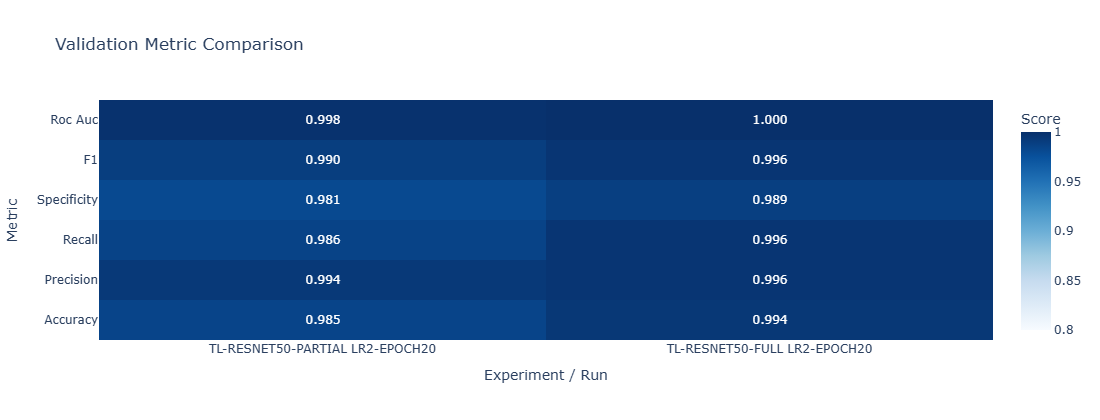

In [46]:
# ============================================================
# 5. Experiment Comparison
# 5-1. Classification Metrics
# ============================================================

import importlib
import cxp.cxp_plot as cxp_plot

importlib.reload(cxp_plot)

cxp_plot.plot_metric_comparison(
    validation_results_df,
    score_range=(0.8, 1.0), 
)

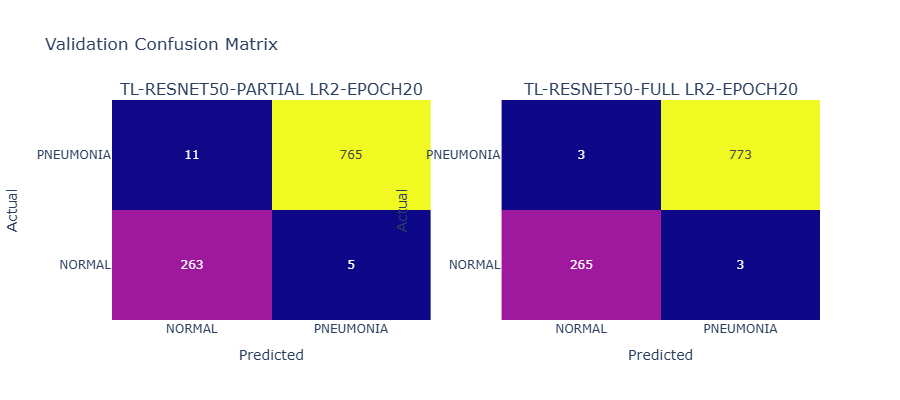

In [44]:
# ============================================================
# 5-2. Confusion Matrix
# ============================================================

cxp_plot.plot_confusion_matrix_comparison(
    validation_results_df
)
 

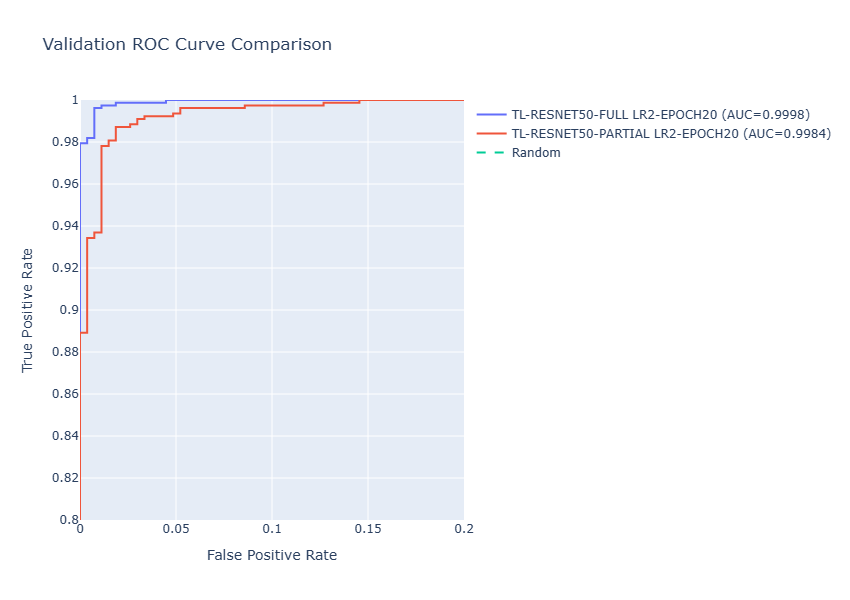

In [57]:
# ============================================================
# 5-3. ROC Curve
# ============================================================

import importlib
import cxp.cxp_plot as cxp_plot

importlib.reload(cxp_plot)

cxp_plot.plot_roc_curve_comparison(
    validation_predictions,
    x_range=(0.0, 0.2),
    y_range=(0.8, 1.0),
)

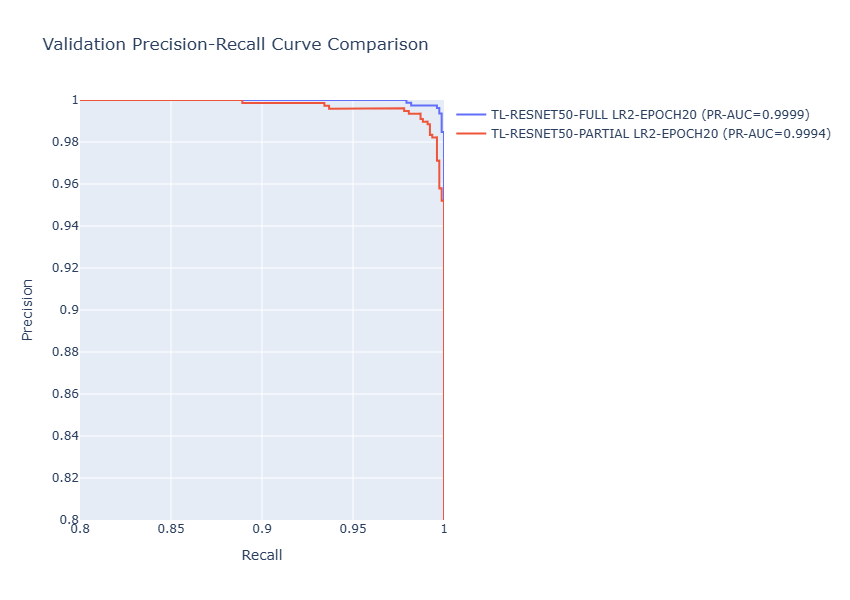

In [50]:
# ============================================================
# 5-4. PR Curve
# ============================================================

cxp_plot.plot_pr_curve_comparison(
    validation_predictions,
    x_range=(0.8, 1.0),
    y_range=(0.8, 1.0),
)

### 6. Learning Curve — Loss

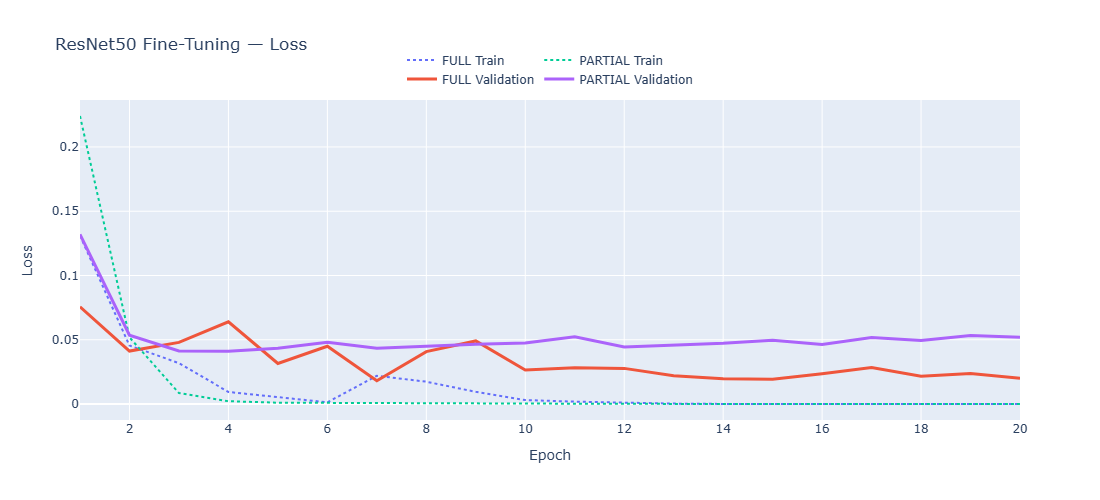

In [52]:
# ============================================================
# 6. Learning Curve
# 6-1. Validation Loss
# ============================================================

cxp_plot.plot_finetuning_history(
    history=history_df,
    experiment_runs=SELECTED_RUNS,
    metric="loss",
)

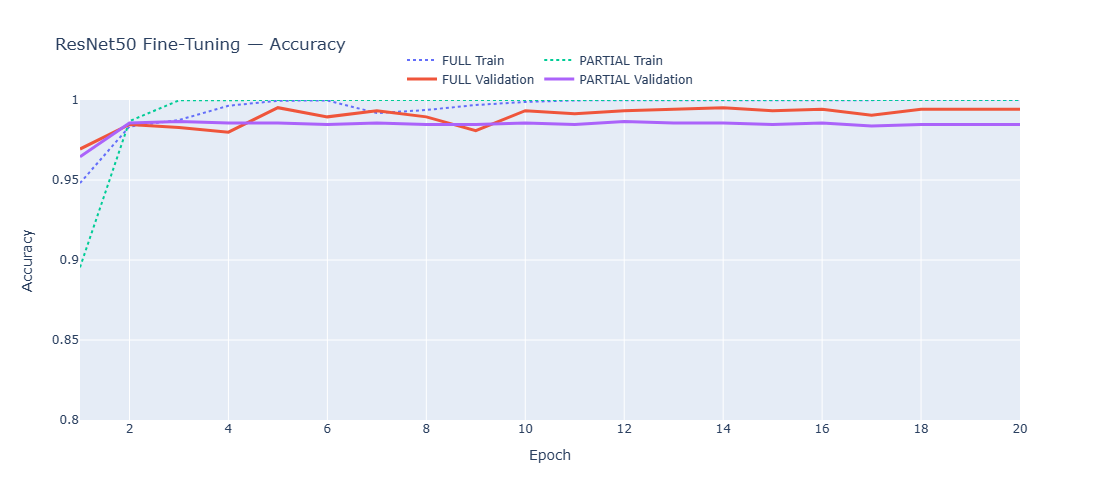

In [53]:
# ============================================================
# 6-2. Validation Accuracy
# ============================================================

cxp_plot.plot_finetuning_history(
    history=history_df,
    experiment_runs=SELECTED_RUNS,
    metric="accuracy",
    y_range=(0.8, 1.0),
)

### 7. Error Analysis

#### -1-1. FP / FN Data

In [54]:
# ============================================================
# 7-1. Error Analysis
# 7-1-1. FP / FN Data
# ============================================================

error_results = {}

for experiment, run in SELECTED_RUNS:

    prediction_result = validation_predictions[
        (experiment, run)
    ]

    error_df = val_df.copy().reset_index(drop=True)

    error_df["y_true"] = prediction_result["labels"]
    error_df["y_pred"] = prediction_result["predictions"]
    error_df["y_prob"] = prediction_result["probabilities"]

    # --------------------------------------------------------
    # False Positive
    # Actual: NORMAL
    # Predicted: PNEUMONIA
    # --------------------------------------------------------

    fp_df = error_df[
        (error_df["y_true"] == 0)
        & (error_df["y_pred"] == 1)
    ].copy()

    # --------------------------------------------------------
    # False Negative
    # Actual: PNEUMONIA
    # Predicted: NORMAL
    # --------------------------------------------------------

    fn_df = error_df[
        (error_df["y_true"] == 1)
        & (error_df["y_pred"] == 0)
    ].copy()

    error_results[(experiment, run)] = {
        "error_df": error_df,
        "fp_df": fp_df,
        "fn_df": fn_df,
    }

    print(f"Run: {experiment} / {run}")
    print(f"False Positive: {len(fp_df)}")
    print(f"False Negative: {len(fn_df)}")
    print()

Run: TL-RESNET50-FULL / LR2-EPOCH20
False Positive: 3
False Negative: 3

Run: TL-RESNET50-PARTIAL / LR2-EPOCH20
False Positive: 5
False Negative: 11



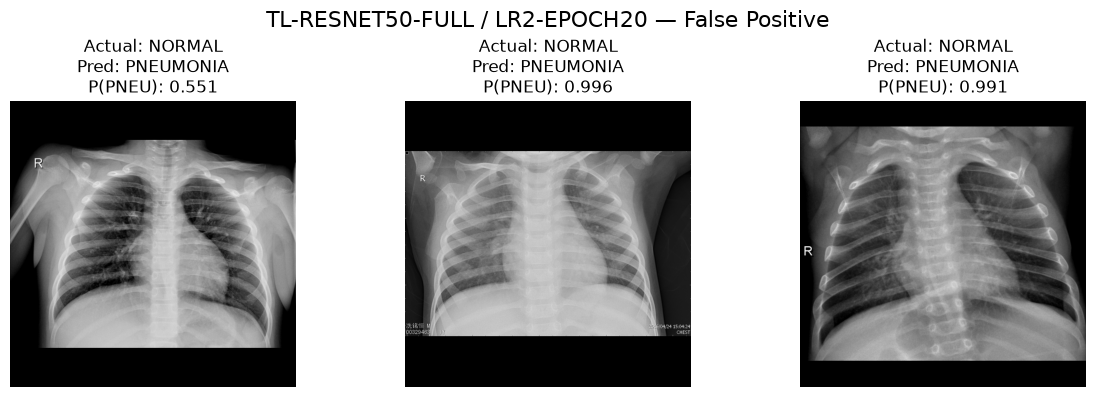

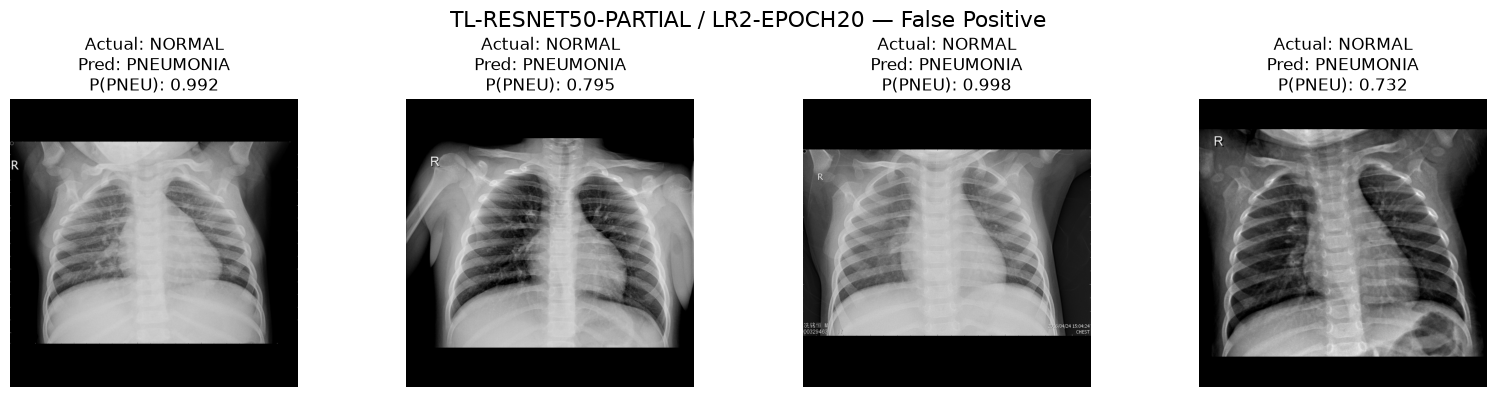

In [59]:
# ============================================================
# 7-1-2. False Positive
# ============================================================


import importlib
import cxp.cxp_plot as cxp_plot

importlib.reload(cxp_plot)



for experiment, run in SELECTED_RUNS:

    fp_df = error_results[(experiment, run)]["fp_df"]

    cxp_plot.show_error_images(
        dataframe=fp_df,
        data_dir=DATASET_TRAIN_DIR,
        idx_to_class=IDX_TO_CLASS,
        n=4,
        title=f"{experiment} / {run} — False Positive",
    )

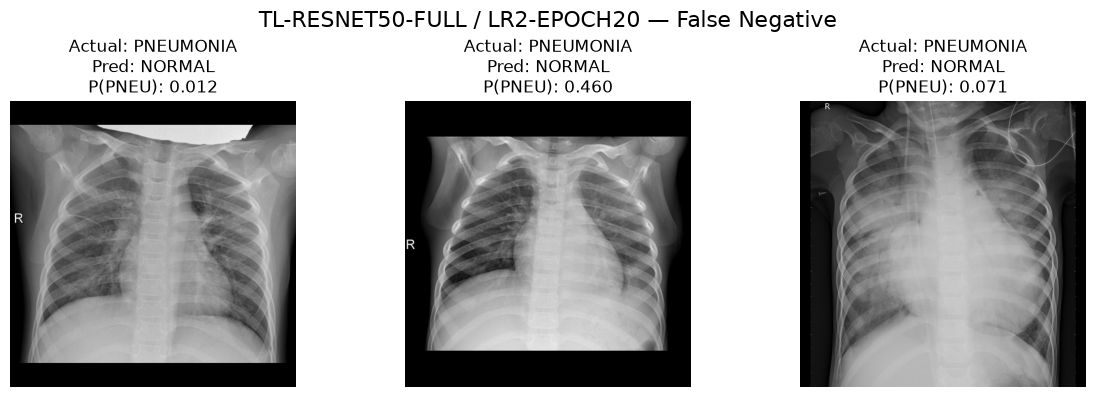

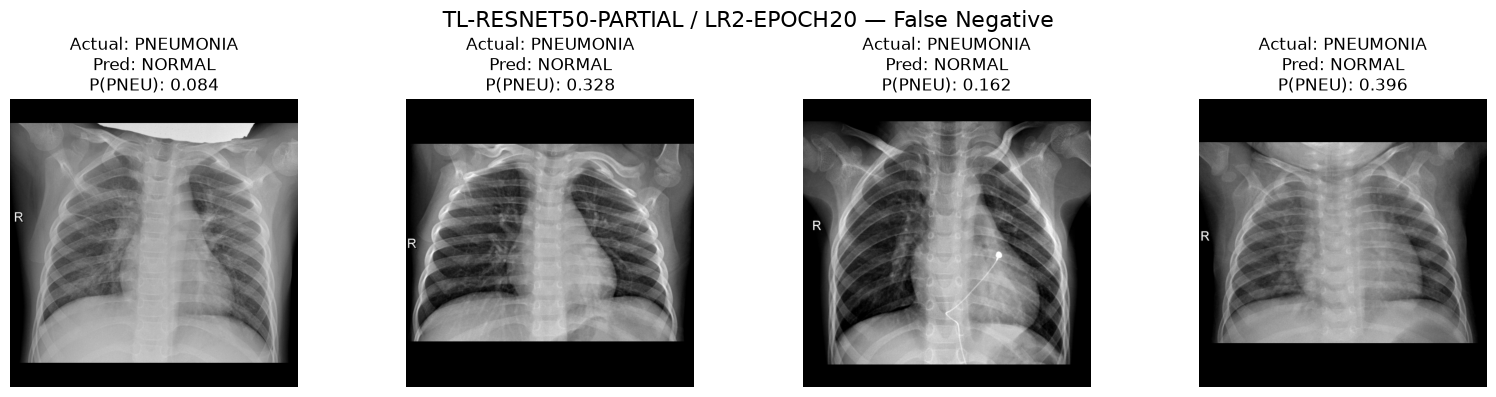

In [61]:
# ============================================================
# 7-1-3. False Negative
# ============================================================

for experiment, run in SELECTED_RUNS:

    fn_df = error_results[(experiment, run)]["fn_df"]

    cxp_plot.show_error_images(
        dataframe=fn_df,
        data_dir=DATASET_TRAIN_DIR,
        idx_to_class=IDX_TO_CLASS,
        n=4,
        title=f"{experiment} / {run} — False Negative",
    )

#### 7-2. Confidence-based Error Analysis

In [62]:
# ============================================================
# 7-2. Confidence-based Error Analysis
# ============================================================

confidence_results = {}

for experiment, run in SELECTED_RUNS:

    fp_df = error_results[(experiment, run)]["fp_df"].copy()
    fn_df = error_results[(experiment, run)]["fn_df"].copy()

    # --------------------------------------------------------
    # False Positive
    # Actual: NORMAL
    # Predicted: PNEUMONIA
    # --------------------------------------------------------

    fp_df["confidence"] = fp_df["y_prob"]

    fp_high_conf = (
        fp_df
        .sort_values(
            "confidence",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # False Negative
    # Actual: PNEUMONIA
    # Predicted: NORMAL
    # --------------------------------------------------------

    fn_df["confidence"] = 1 - fn_df["y_prob"]

    fn_high_conf = (
        fn_df
        .sort_values(
            "confidence",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    confidence_results[(experiment, run)] = {
        "fp": fp_high_conf,
        "fn": fn_high_conf,
    }

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    print(f"Run: {experiment} / {run}")

    print(f"\nFalse Positive: {len(fp_high_conf)}")
    display(
        fp_high_conf[
            [
                "Folder",
                "File",
                "y_true",
                "y_pred",
                "y_prob",
                "confidence",
            ]
        ].head(10)
    )

    print(f"\nFalse Negative: {len(fn_high_conf)}")
    display(
        fn_high_conf[
            [
                "Folder",
                "File",
                "y_true",
                "y_pred",
                "y_prob",
                "confidence",
            ]
        ].head(10)
    )

Run: TL-RESNET50-FULL / LR2-EPOCH20

False Positive: 3


,Folder,File,y_true,y_pred,y_prob,confidence
0,NORMAL,NORMAL2-IM-0611-0001.png,0,1,0.996192,0.996192
1,NORMAL,IM-0647-0001.png,0,1,0.990984,0.990984
2,NORMAL,IM-0517-0001.png,0,1,0.550969,0.550969



False Negative: 3


,Folder,File,y_true,y_pred,y_prob,confidence
0,PNEUMONIA,person277_virus_571.png,1,0,0.011893,0.988107
1,PNEUMONIA,person994_bacteria_2922.png,1,0,0.071021,0.928979
2,PNEUMONIA,person301_virus_622.png,1,0,0.460475,0.539525


Run: TL-RESNET50-PARTIAL / LR2-EPOCH20

False Positive: 5


,Folder,File,y_true,y_pred,y_prob,confidence
0,NORMAL,NORMAL2-IM-0611-0001.png,0,1,0.998414,0.998414
1,NORMAL,NORMAL2-IM-1250-0001.png,0,1,0.991706,0.991706
2,NORMAL,NORMAL2-IM-1365-0001.png,0,1,0.991382,0.991382
3,NORMAL,IM-0517-0001.png,0,1,0.794845,0.794845
4,NORMAL,NORMAL2-IM-0977-0001.png,0,1,0.732213,0.732213



False Negative: 11


,Folder,File,y_true,y_pred,y_prob,confidence
0,PNEUMONIA,person301_virus_622.png,1,0,0.002311,0.997689
1,PNEUMONIA,person702_virus_1299.png,1,0,0.004363,0.995637
2,PNEUMONIA,person781_virus_1412.png,1,0,0.032867,0.967133
3,PNEUMONIA,person277_virus_571.png,1,0,0.083830,0.916170
4,PNEUMONIA,person1489_virus_2594.png,1,0,0.089076,0.910924
5,PNEUMONIA,person104_virus_191.png,1,0,0.099764,0.900236
6,PNEUMONIA,person1023_bacteria_2954.png,1,0,0.162328,0.837672
7,PNEUMONIA,person384_bacteria_1755.png,1,0,0.254438,0.745562
8,PNEUMONIA,person302_virus_623.png,1,0,0.276411,0.723589
9,PNEUMONIA,person820_virus_1456.png,1,0,0.327584,0.672416


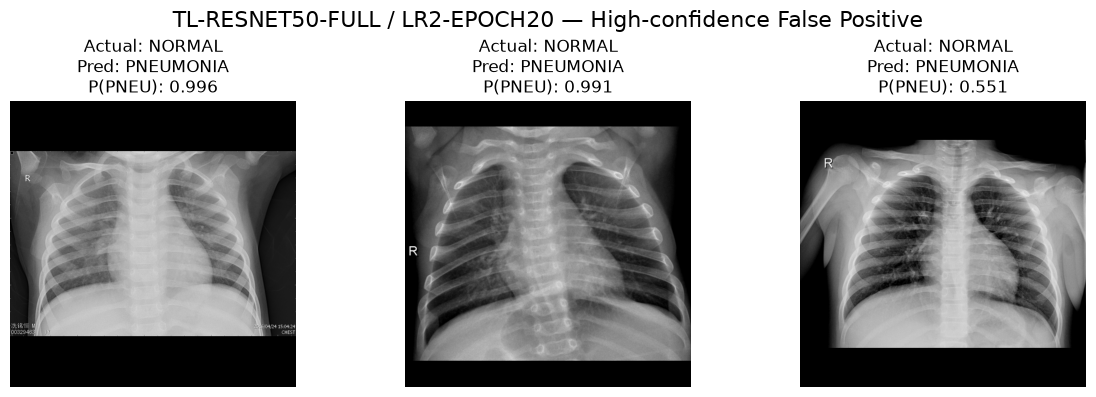

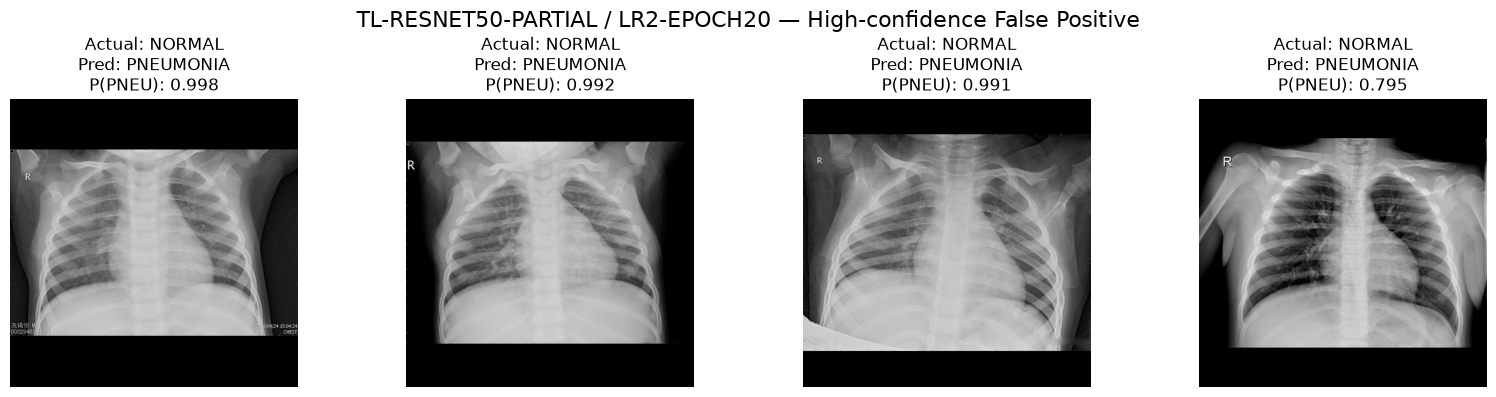

In [64]:
# ============================================================
# 7-2-1. High-confidence False Positive
# ============================================================

for experiment, run in SELECTED_RUNS:

    fp_high_conf = confidence_results[
        (experiment, run)
    ]["fp"]

    cxp_plot.show_error_images(
        dataframe=fp_high_conf,
        data_dir=DATASET_TRAIN_DIR,
        idx_to_class=IDX_TO_CLASS,
        n=4,
        title=f"{experiment} / {run} — High-confidence False Positive",
    )

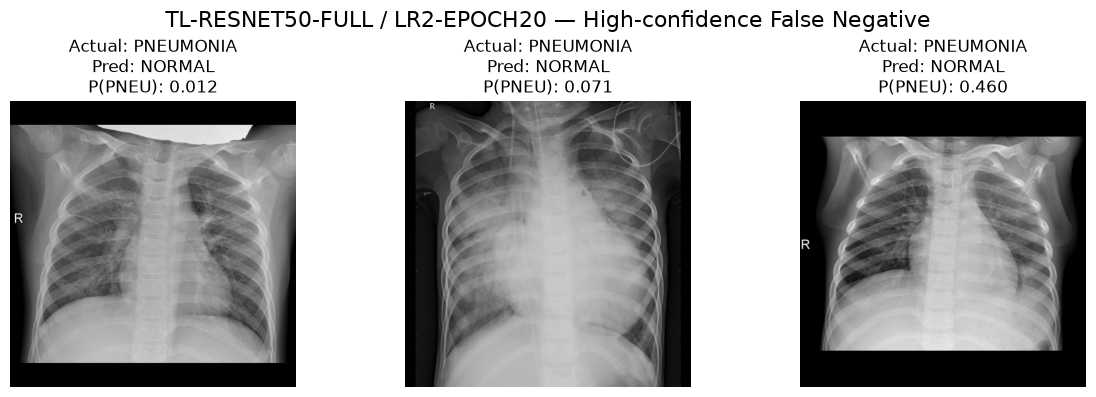

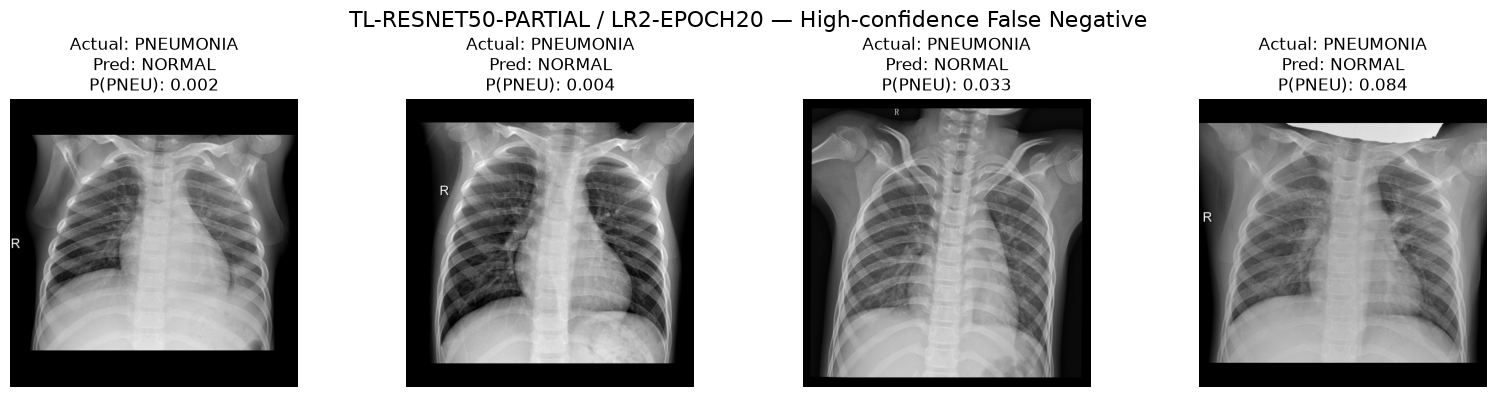

In [65]:
# ============================================================
# 7-2-2. High-confidence False Negative
# ============================================================

for experiment, run in SELECTED_RUNS:

    fn_high_conf = confidence_results[
        (experiment, run)
    ]["fn"]

    cxp_plot.show_error_images(
        dataframe=fn_high_conf,
        data_dir=DATASET_TRAIN_DIR,
        idx_to_class=IDX_TO_CLASS,
        n=4,
        title=f"{experiment} / {run} — High-confidence False Negative",
    )

#### 7-3 Grad-CAM

In [ ]:
# ============================================================
# 7-3. Grad-CAM
# ============================================================

import importlib
import cxp.cxp_gradcam as cxp_gradcam

importlib.reload(cxp_gradcam)

<module 'cxp.cxp_gradcam' from 'D:\\DEV\\AI\\projects\\chest-xray-pneumonia\\cxp\\cxp_gradcam.py'>

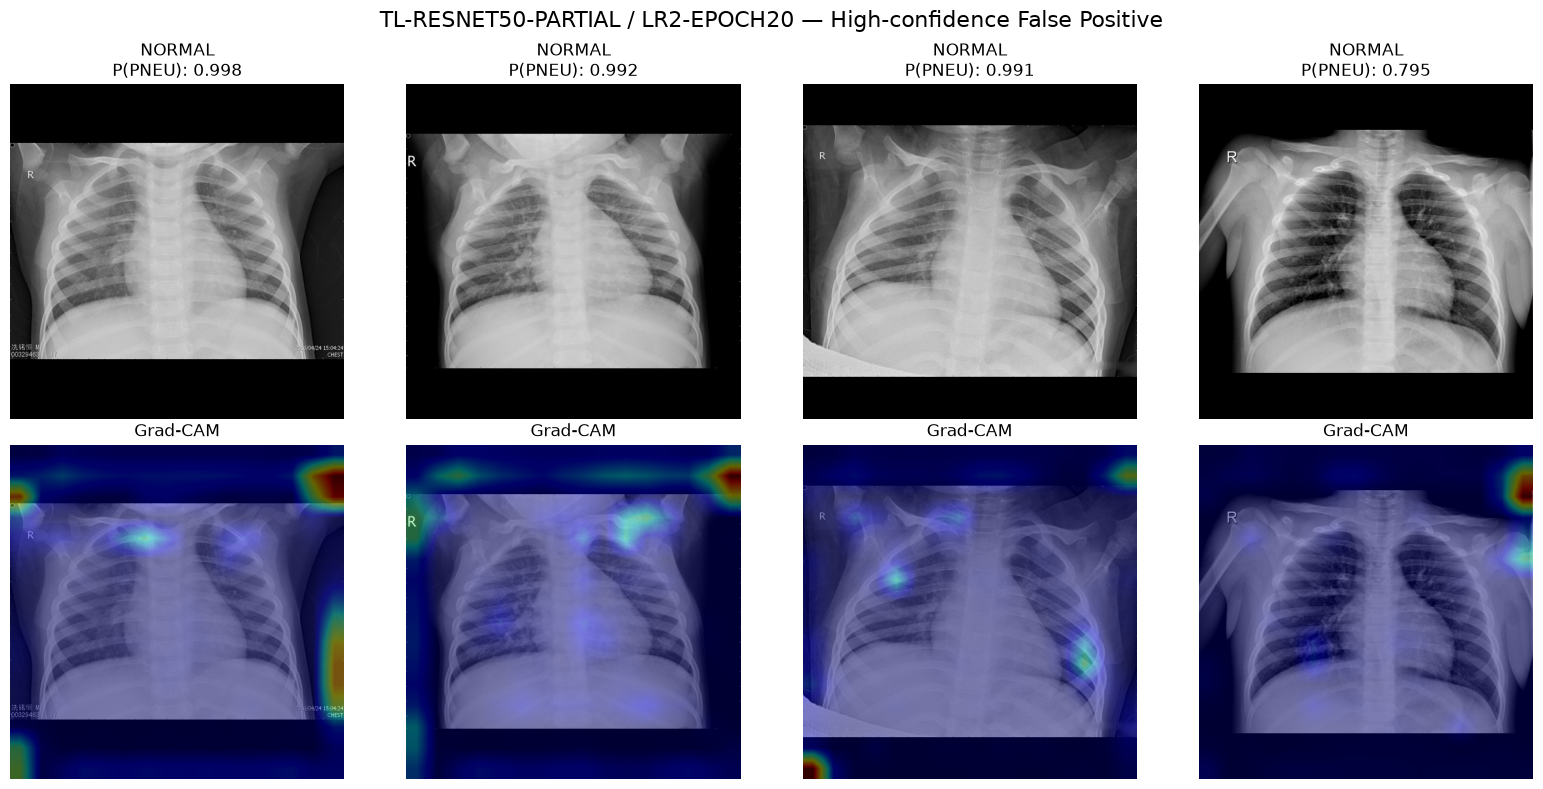

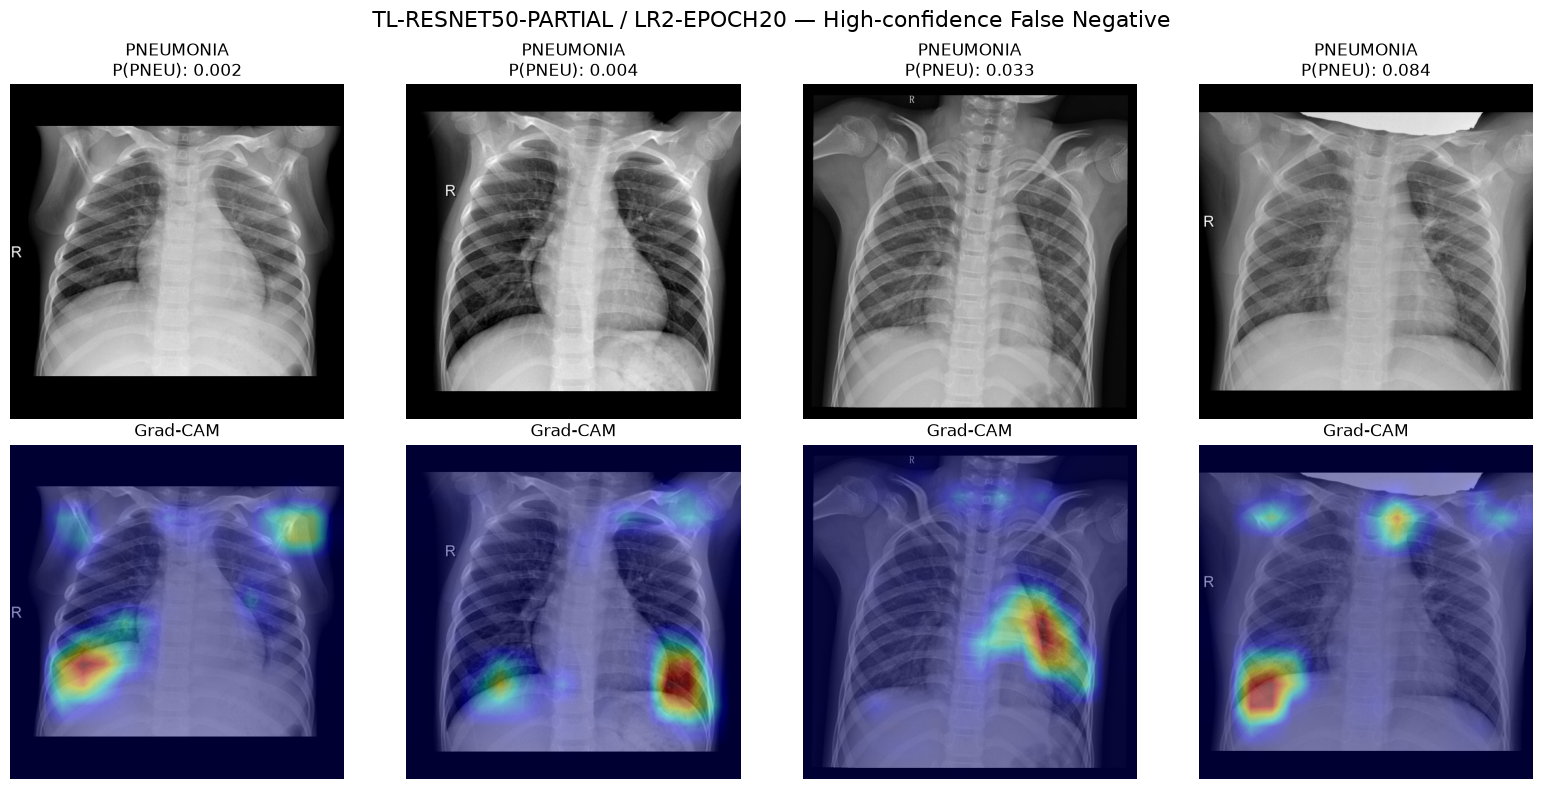

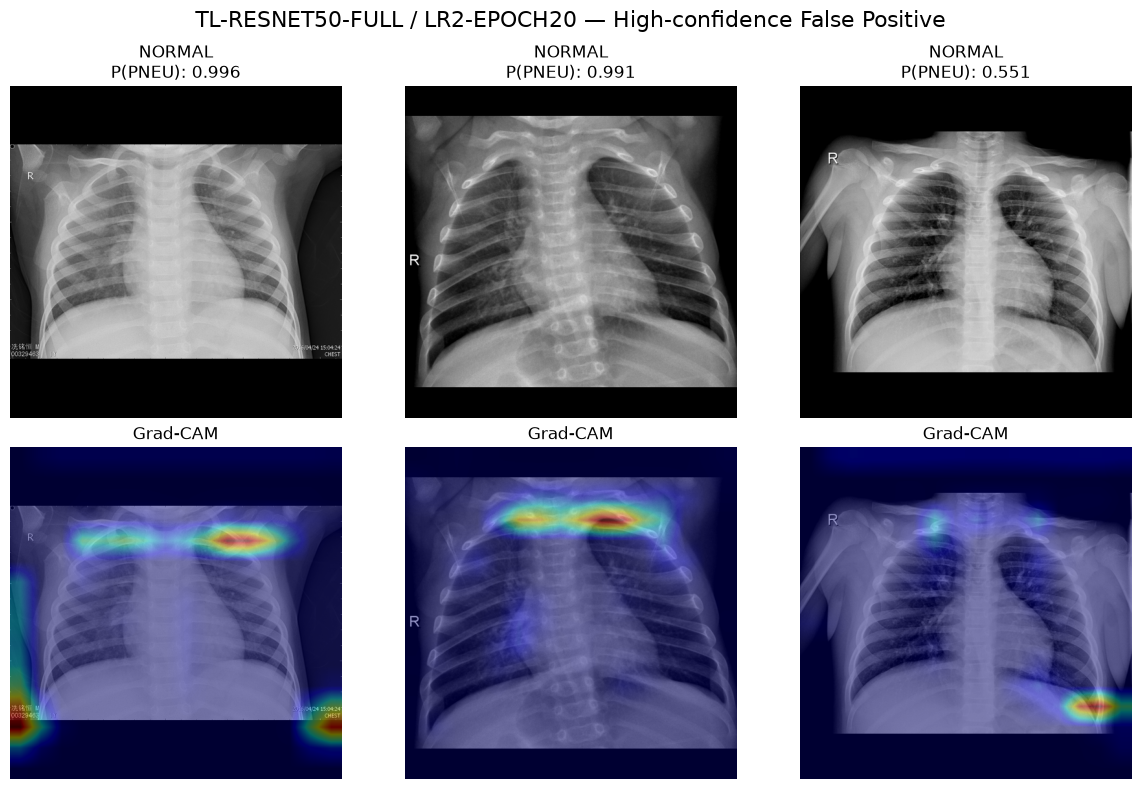

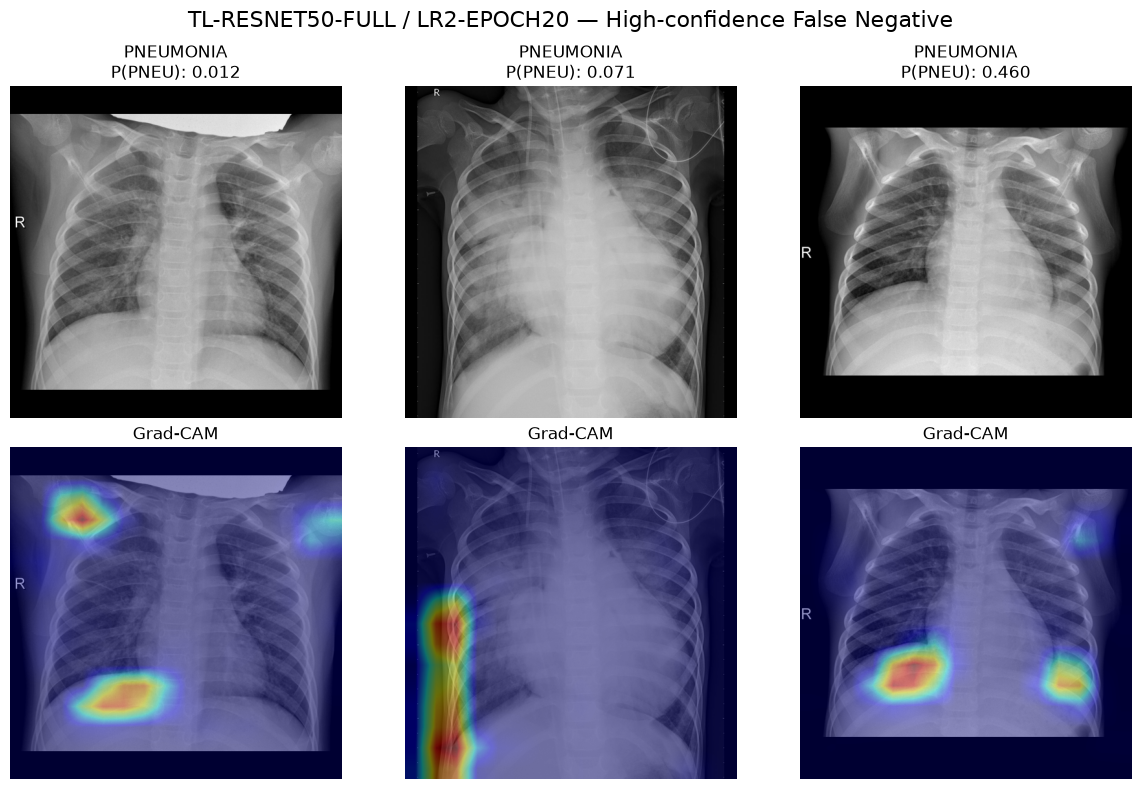

In [67]:
# ============================================================
# 7-3-2. FP / FN Grad-CAM Comparison
# ============================================================

from cxp import cxp_gradcam

N_SAMPLES = 4
SELECTED_RUNS = [
    ("TL-RESNET50-PARTIAL", "LR2-EPOCH20"),
    ("TL-RESNET50-FULL", "LR2-EPOCH20"),
]

for experiment, run in SELECTED_RUNS:

    # --------------------------------------------------------
    # Experiment / Run 정보
    # --------------------------------------------------------

    run_info = selected_summary[
        (selected_summary["experiment"] == experiment)
        & (selected_summary["run"] == run)
    ].iloc[0]

    # --------------------------------------------------------
    # Load Model
    # --------------------------------------------------------

    model = load_experiment_model(run_info)

    target_layer = cxp_gradcam.get_gradcam_target_layer(
        model=model,
        model_name=run_info["model"],
    )

    gradcam = cxp_gradcam.GradCAM(
        model=model,
        target_layer=target_layer,
    )

    # --------------------------------------------------------
    # Evaluation Transform
    # --------------------------------------------------------

    eval_transform = create_transform(
        image_size=IMAGE_SIZE,
        mean=NORMALIZATION["mean"],
        std=NORMALIZATION["std"],
    )

    # --------------------------------------------------------
    # High-confidence False Positive
    # --------------------------------------------------------

    fp_high_conf = confidence_results[
        (experiment, run)
    ]["fp"]

    cxp_gradcam.plot_gradcam_samples(
        dataframe=fp_high_conf,
        gradcam=gradcam,
        transform=eval_transform,
        image_dir=DATASET_TRAIN_DIR,
        n_samples=N_SAMPLES,
        title_prefix=(
            f"{experiment} / {run} — "
            f"High-confidence False Positive"
        ),
        device=DEVICE,
    )

    # --------------------------------------------------------
    # High-confidence False Negative
    # --------------------------------------------------------

    fn_high_conf = confidence_results[
        (experiment, run)
    ]["fn"]

    cxp_gradcam.plot_gradcam_samples(
        dataframe=fn_high_conf,
        gradcam=gradcam,
        transform=eval_transform,
        image_dir=DATASET_TRAIN_DIR,
        n_samples=N_SAMPLES,
        title_prefix=(
            f"{experiment} / {run} — "
            f"High-confidence False Negative"
        ),
        device=DEVICE,
    )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    cxp_gradcam.cleanup_gradcam(
        gradcam=gradcam,
        model=model,
    )

***Grad-CAM 기반 Error Analysis***  

False Positive 사례에서 Grad-CAM을 확인한 결과, 활성 영역이 폐 실질에만 집중되지 않고 심장·종격동, 하부 흉부 및 영상 가장자리 등 여러 영역에 분산되는 사례가 확인되었다.
일부 사례에서는 PNEUMONIA 확률이 0.9 이상으로 높게 나타났으며, 모델이 폐렴 관련 특징 외에 영상의 배경이나 촬영 특성에 영향을 받았을 가능성도 확인하였다.
False Negative 사례에서는 폐 내부 및 하부 흉부 영역에서 활성 영역이 관찰되었으나, 해당 특징을 PNEUMONIA로 충분히 구분하지 못한 사례가 확인되었다.
따라서 오류 개선을 위해 영상의 불필요한 주변 영역을 줄이는 Crop 등의 전처리와 Fine-Tuning을 통한 추가 학습을 고려할 수 있다.
단, Grad-CAM은 모델의 예측에 영향을 준 영역을 시각화하는 도구이므로 실제 병변 위치나 의학적 판단 근거로 해석하지 않았다.


#### 7-4 Error Analysis 

Validation set 1,044개에서 Partial은 Correct 1,028, FP 5, FN 11이 발생하였고, Full은 Correct 1,038, FP 3, FN 3이 발생하였다.

* **FP:** Partial 5건, Full 3건으로 일부 사례에서 높은 확신으로 NORMAL을 PNEUMONIA로 예측
* **FN:** Partial 11건, Full 3건으로 Partial에서 더 많이 발생했으며, 일부 사례에서 PNEUMONIA 확률이 낮게 나타남
* **Grad-CAM:** 일부 오류 사례에서 활성 영역이 특정 폐 영역에 집중되지 않고 심장·종격동, 하부 흉부 및 영상 가장자리 등 여러 영역에 분산되는 사례가 확인됨

Grad-CAM은 모델의 예측에 영향을 준 영역을 시각화하는 도구이므로 실제 병변 위치나 의학적 판단 근거로 해석하지 않았다.


#### ----------------------------------------------------------------------------------------------------------------------------------------------------

### 8. Experiment Comment

#### Experiment Objective

**ResNet50에서 Fine-Tuning 방식에 따른 성능 차이를 비교한다.**

* Model: ResNet50
* Training Mode: Partial / Full
* Optimizer: Adam
* Epochs: 20
* Input Size: 512 × 512
* Normalization: ImageNet Mean / Std
* Loss: CrossEntropy
* Learning Rate: LR2 (1e-4)

#### Result

| Metric      | Partial |   Full |
| ----------- | ------: | -----: |
| Accuracy    |  0.9847 | 0.9943 |
| Precision   |  0.9935 | 0.9961 |
| Recall      |  0.9858 | 0.9961 |
| Specificity |  0.9813 | 0.9888 |
| F1          |  0.9897 | 0.9961 |
| ROC-AUC     |  0.9984 | 0.9998 |
| TN          |     263 |    265 |
| FP          |       5 |      3 |
| FN          |      11 |      3 |
| TP          |     765 |    773 |

#### Interpretation

* **Partial:** Accuracy 0.9847, F1 0.9897, ROC-AUC 0.9984로 높은 Validation 성능을 보임
* **Full:** Accuracy 0.9943, F1 0.9961, ROC-AUC 0.9998로 Partial보다 모든 주요 지표에서 개선됨
* **Error Analysis:** Partial은 FP 5, FN 11이 발생했으며, Full에서는 FP 3, FN 3으로 감소함
* **Grad-CAM:** 일부 오류 사례에서 활성 영역이 특정 폐 영역에 집중되지 않고 심장·종격동, 하부 흉부 및 영상 가장자리 등 여러 영역에 분산되는 사례가 확인됨

#### Decision

**Selected Fine-Tuning Method: Full**

Partial과 Full 모두 높은 Validation 성능을 보였으며, **Full Fine-Tuning에서 Accuracy, Precision, Recall, Specificity, F1, ROC-AUC가 모두 개선되고 FP/FN도 감소하였다.** 따라서 이후 ResNet50 실험에서는 Full Fine-Tuning을 기준으로 사용한다.

#### Next Experiment

선정한 **Full Fine-Tuning + LR2 (1e-4)을 적용**하고, Validation 성능 및 Error Analysis 결과를 기준으로 최종 모델을 비교한다.
